
# Part 4 — Simple Error Mitigation

Parts 2–3 characterized noise; this part does something about it, in the simplest way that still
teaches the right lesson. The **3-qubit bit-flip repetition code** encodes one logical bit into
three physical qubits and recovers it by **majority vote** — no ancillas, no syndrome measurement,
just a classical error-correcting idea (repeat and vote) ported onto qubits. It is deliberately a
toy: understanding *exactly* what it does and doesn't protect against is the actual goal, since
that gap is what motivates real quantum error correction (QEC).

**Goals**

1. Derive the majority-vote logical error rate from first principles (a binomial tail) and connect
   it to the user's probability background (order statistics).
2. Implement encode/decode and verify it recovers computational-basis inputs exactly, noiselessly.
3. Demonstrate the mitigation: theoretical curve, Monte Carlo estimate, and the "no mitigation"
   baseline, together, with the $p=0.5$ crossover called out.
4. Show — not just assert — the limitation: this code protects against bit flips only. A
   computational-basis input makes phase-flip noise *invisible* to majority vote (a striking, exact
   result), while a superposition input reveals the real fidelity loss majority vote can't see.
5. Explain precisely why this isn't full QEC, and what real QEC does differently.


In [1]:

import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix, Statevector, state_fidelity

from src.circuits import add_idle_layers, add_measurements
from src.error_mitigation import (
    logical_error_rate_theoretical,
    majority_vote_decode,
    repetition_encode,
)
from src.experiment_utils import apply_noise_layers
from src.noise_models import bit_flip_kraus, phase_flip_kraus, single_qubit_noise_model
from src.simulation import sample_counts
from src.visualization import CATEGORICAL_COLORS, plot_mitigation_comparison

%matplotlib inline



## Deriving the logical error rate

Encode a logical bit as 3 physical qubits, all prepared identically (2 CNOTs from qubit 0). Each
physical qubit then independently suffers a bit flip with probability $p$. Majority vote decodes
correctly unless **2 or more** of the 3 physical qubits flip — a direct binomial tail:

$$
p_{\text{logical}} = P[\text{Binomial}(3, p) \ge 2] = \binom{3}{2}p^2(1-p) + \binom{3}{3}p^3
= 3p^2 - 2p^3
$$

This is exactly the majority-vote/order-statistic argument from classical coding theory: 3
independent noisy copies, keep whichever value the *majority* agrees on. Two sanity checks worth
having in mind before running anything: $p_{\text{logical}}(0) = 0$, $p_{\text{logical}}(1) = 1$
(certainty in, certainty out — flipping *all three* every time is just relabeling), and — less
obviously — $p_{\text{logical}}(0.5) = 3(0.25) - 2(0.125) = 0.5$ exactly: at $p=0.5$ each physical
qubit is a fair coin, so majority vote is *also* a fair coin, no better and no worse.


In [2]:

ps = np.linspace(0, 1, 11)
for p in ps:
    binomial_tail = sum(math.comb(3, k) * p**k * (1 - p) ** (3 - k) for k in (2, 3))
    print(f"p={p:.1f}  3p^2-2p^3={logical_error_rate_theoretical(p):.4f}  "
          f"binomial tail (independent calc)={binomial_tail:.4f}")


p=0.0  3p^2-2p^3=0.0000  binomial tail (independent calc)=0.0000
p=0.1  3p^2-2p^3=0.0280  binomial tail (independent calc)=0.0280
p=0.2  3p^2-2p^3=0.1040  binomial tail (independent calc)=0.1040
p=0.3  3p^2-2p^3=0.2160  binomial tail (independent calc)=0.2160
p=0.4  3p^2-2p^3=0.3520  binomial tail (independent calc)=0.3520
p=0.5  3p^2-2p^3=0.5000  binomial tail (independent calc)=0.5000
p=0.6  3p^2-2p^3=0.6480  binomial tail (independent calc)=0.6480
p=0.7  3p^2-2p^3=0.7840  binomial tail (independent calc)=0.7840
p=0.8  3p^2-2p^3=0.8960  binomial tail (independent calc)=0.8960
p=0.9  3p^2-2p^3=0.9720  binomial tail (independent calc)=0.9720
p=1.0  3p^2-2p^3=1.0000  binomial tail (independent calc)=1.0000



## Encoding and noiseless recovery

`repetition_encode` takes a 1-qubit circuit and returns a 3-qubit circuit: the input is copied onto
qubits 1 and 2 via 2 CNOTs. `majority_vote_decode` then collapses raw 3-bit measurement counts to a
decoded logical bit. With no noise, encoding $|0\rangle$ or $|1\rangle$ and decoding must recover
the input exactly.


In [3]:

encoded_0 = repetition_encode(QuantumCircuit(1))
print(encoded_0.draw())

message_1 = QuantumCircuit(1)
message_1.x(0)
encoded_1 = repetition_encode(message_1)

for label, enc in (("|0>", encoded_0), ("|1>", encoded_1)):
    counts = sample_counts(add_measurements(enc), shots=1024, seed=42)
    print(f"encoded {label}: raw counts = {counts}  ->  decoded = {majority_vote_decode(counts)}")


               
q_0: ──■────■──
     ┌─┴─┐  │  
q_1: ┤ X ├──┼──
     └───┘┌─┴─┐
q_2: ─────┤ X ├
          └───┘
encoded |0>: raw counts = {'000': 1024}  ->  decoded = {'0': 1024, '1': 0}
encoded |1>: raw counts = {'111': 1024}  ->  decoded = {'0': 0, '1': 1024}



## Does majority vote actually help?

Sweep the physical bit-flip probability $p$, apply independent bit-flip noise to each of the 3
physical qubits (via a single idle layer, the same noise-injection convention as Parts 2–3), decode
by majority vote, and compare the empirical logical error rate against the theoretical curve and
the "no mitigation" $y=p$ baseline.


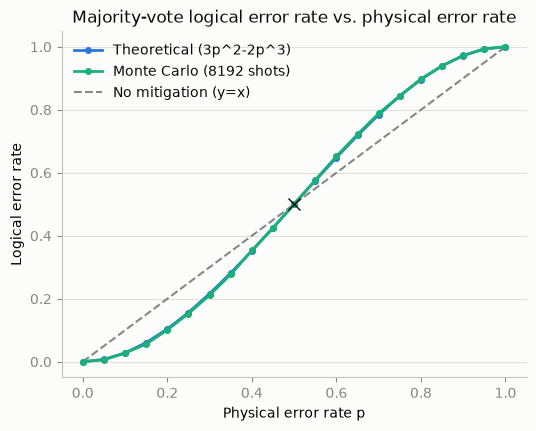

In [4]:

params = np.round(np.arange(0.0, 1.01, 0.05), 2)
encoded = repetition_encode(QuantumCircuit(1))
measured_qc = add_measurements(add_idle_layers(encoded, 1))

empirical = []
for p in params:
    noise_model = single_qubit_noise_model(bit_flip_kraus(p), qubits=[0, 1, 2], gate="id")
    counts = sample_counts(measured_qc, shots=8192, seed=42, noise_model=noise_model)
    decoded = majority_vote_decode(counts)
    empirical.append(decoded["1"] / sum(decoded.values()))

theoretical = [logical_error_rate_theoretical(p) for p in params]

plot_mitigation_comparison(
    params,
    {"Theoretical (3p^2-2p^3)": theoretical, "Monte Carlo (8192 shots)": empirical},
    title="Majority-vote logical error rate vs. physical error rate",
)
plt.show()



**Reading the plot.** Below $p=0.5$, majority vote pulls the logical error rate well *below* the
physical rate — the mitigation is working, and the effect is strongest for small $p$ (a $p=0.1$
physical rate becomes roughly a $0.03$ logical rate: an order of magnitude improvement, since two
independent flips are needed to fool the vote). Above $p=0.5$, the curve crosses *above* the
diagonal: when a single physical qubit is already more likely to be wrong than right, three
independent votes for the *wrong* answer become more likely too — majority vote of unreliable
inputs amplifies the unreliability, rather than fixing it. This is why $p=0.5$ isn't just a
convenient closed-form root; it's the exact point where "more copies" stops being useful information
at all.



## The limitation, demonstrated: this code only catches bit flips

The repetition code above encodes by copying a **Z-basis** value onto 3 qubits, and decodes by a
**Z-basis** measurement + majority vote. What happens if the noise is a *phase* flip ($Z$) instead
of a bit flip ($X$)?

For a computational-basis input, the answer is almost embarrassingly simple: $Z|0\rangle = |0\rangle$
(up to an unobservable global phase) and $Z|1\rangle=-|1\rangle$ similarly. A phase flip **does
nothing at all** to a $Z$-eigenstate — not "something the code corrects," but literally no
observable effect, at any $p$. So majority vote will report **zero logical error, always**, which
looks like perfect protection but is actually a measurement blind spot, not a correction. This is
the same phenomenon flagged in Part 3 (fidelity vs. error rate can disagree) taken to its extreme.


In [5]:

encoded = repetition_encode(QuantumCircuit(1))
measured_qc = add_measurements(add_idle_layers(encoded, 1))

for p in (0.1, 0.5, 1.0):
    noise_model = single_qubit_noise_model(phase_flip_kraus(p), qubits=[0, 1, 2], gate="id")
    counts = sample_counts(measured_qc, shots=8192, seed=42, noise_model=noise_model)
    decoded = majority_vote_decode(counts)
    print(f"phase-flip p={p:.1f}: decoded counts = {decoded}  (looks perfect -- but is it?)")


phase-flip p=0.1: decoded counts = {'0': 8192, '1': 0}  (looks perfect -- but is it?)
phase-flip p=0.5: decoded counts = {'0': 8192, '1': 0}  (looks perfect -- but is it?)


phase-flip p=1.0: decoded counts = {'0': 8192, '1': 0}  (looks perfect -- but is it?)



It isn't. Encode a **superposition** ($|+\rangle$, giving $(|000\rangle+|111\rangle)/\sqrt2$,
structurally a GHZ state) instead of a computational basis state, and check the true quantum state
fidelity — not the classical decoded bit, which for a superposition input has no well-defined
"correct answer" under a $Z$-basis measurement anyway — after the same phase-flip noise.


In [6]:

message_plus = QuantumCircuit(1)
message_plus.h(0)
ideal_rho = DensityMatrix(Statevector.from_instruction(repetition_encode(message_plus)))

print(f"{'p':>5} {'fidelity':>10}")
for p in (0.0, 0.1, 0.3, 0.5, 0.7, 1.0):
    noisy_rho = apply_noise_layers(ideal_rho, phase_flip_kraus, p, num_layers=1, qubits=[0, 1, 2])
    print(f"{p:5.1f} {state_fidelity(ideal_rho, noisy_rho):10.4f}")


    p   fidelity
  0.0     1.0000
  0.1     0.7560
  0.3     0.5320
  0.5     0.5000
  0.7     0.4680
  1.0     0.0000



Real degradation, invisible to the majority-vote metric above. **The bit-flip repetition code
provides zero protection against phase-flip noise** — the "perfect" logical error rate on
computational-basis inputs was a measurement artifact, not evidence of correction. A code that
protects against *both* error types needs to combine this trick with its Hadamard-conjugate (which
protects $X$-basis information against phase flips, symmetric to how this code protects $Z$-basis
information against bit flips) — which is exactly the construction behind Shor's 9-qubit code, a
stretch-goal topic.



## Why this isn't full quantum error correction

Two related reasons, worth separating:

1. **It only protects one error type.** As just demonstrated, this specific code protects $Z$-basis
   (bit-flip) information and gives no protection to phase information. Protecting against a
   general, unknown error requires a code robust to *both* — the Shor code (9 qubits, this
   repetition code nested inside its Hadamard conjugate) is the historical first example; the
   stabilizer formalism generalizes the idea efficiently.

2. **Majority-vote decoding destroys superpositions.** Even restricted to bit-flip-only noise,
   decoding here means directly measuring all 3 physical qubits in the computational basis. That
   measurement collapses any encoded superposition outright — this code only ever recovers a
   **classical bit value**, never a qubit that can continue being computed on. Real QEC instead
   measures **stabilizers** — parity checks like $Z_1Z_2$ and $Z_2Z_3$, via ancilla qubits — which
   reveal *where* an error occurred (the "syndrome") without ever revealing (and therefore without
   collapsing) the encoded logical state itself, followed by a corrective gate conditioned on the
   syndrome. Syndrome extraction, stabilizer formalism, and surface codes are exactly the stretch
   goals this project defers to, now that the gap this toy leaves behind is concrete rather than
   asserted.



## The full committed sweep

The cells above ran the sweep directly in the notebook. `experiments/run_mitigation_sweep.py`
reproduces the same sweep from the checked-in `experiments/configs/mitigation.toml` (21 values of
$p$, fixed seed) and writes `experiments/results/mitigation_sweep.csv`, confirmed byte-for-byte
reproducible across independent runs.


In [7]:

results = pd.read_csv("../experiments/results/mitigation_sweep.csv")
results


,p,physical_error_rate,logical_error_rate_theoretical,logical_error_rate_empirical
0,0.00,0.00,0.00000,0.000000
1,0.05,0.05,0.00725,0.006592
2,0.10,0.10,0.02800,0.027466
3,0.15,0.15,0.06075,0.056030
4,0.20,0.20,0.10400,0.101074
5,0.25,0.25,0.15625,0.152954
6,0.30,0.30,0.21600,0.211304
7,0.35,0.35,0.28175,0.276978
8,0.40,0.40,0.35200,0.353271
9,0.45,0.45,0.42525,0.424072


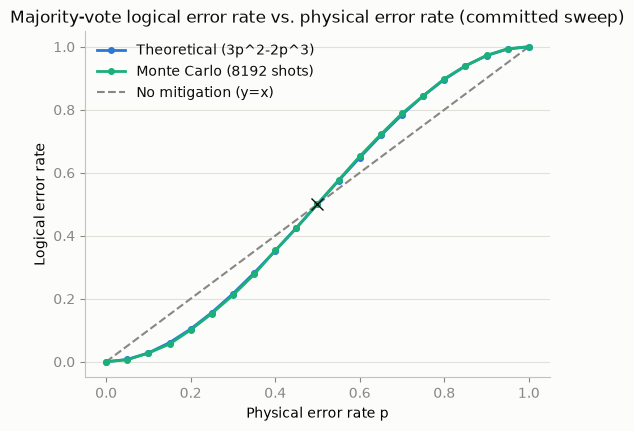

Max |empirical - theoretical| gap across the sweep: 0.0048


In [8]:

plot_mitigation_comparison(
    results["p"],
    {
        "Theoretical (3p^2-2p^3)": results["logical_error_rate_theoretical"],
        "Monte Carlo (8192 shots)": results["logical_error_rate_empirical"],
    },
    title="Majority-vote logical error rate vs. physical error rate (committed sweep)",
)
plt.show()

max_gap = (results["logical_error_rate_empirical"] - results["logical_error_rate_theoretical"]).abs().max()
print(f"Max |empirical - theoretical| gap across the sweep: {max_gap:.4f}")



## Limitations

- **Single fixed seed, one shot count (8192).** No error bars on the Monte Carlo column; the
  theoretical closed form is the reliable reference whenever the two disagree by more than sampling
  noise would predict.
- **Independent, identically-distributed physical-qubit noise.** Real repetition-code hardware
  deployments have to worry about correlated errors (crosstalk) breaking the independence
  assumption the $3p^2-2p^3$ derivation relies on.
- **Only bit-flip noise is "mitigated" here** — by design, to make the limitation concrete (see
  above), not as an oversight.
- **No optimality claim.** 3 physical qubits per logical bit is far from droplet-efficient by real
  QEC standards (surface codes use hundreds); this is the simplest illustration of the core idea,
  not a competitive code.



## Summary

- Derived and verified $3p^2-2p^3$ as the exact majority-vote logical error rate, and located the
  $p=0.5$ crossover where redundancy stops helping and starts hurting.
- Implemented and tested `repetition_encode` / `majority_vote_decode` / `logical_error_rate_theoretical`,
  matching Monte Carlo to the closed form to within sampling noise.
- Demonstrated, not just asserted, that this code gives **zero protection against phase-flip
  noise** — an exact, striking result for computational-basis inputs (phase flip is literally
  invisible to $Z$-basis measurement) with real fidelity loss recoverable only by checking a
  superposition input directly.
- Explained precisely why this isn't full QEC: single-error-type coverage, and
  measurement-destroys-superposition decoding — both gaps that motivate the stabilizer-formalism
  stretch goals.

Interview-style Q&A generated while building this notebook is logged in
`docs/interview_questions.md`, not repeated here.
